In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"

print(PROJECT_ROOT)
print(RESULTS_DIR)

C:\code\korea-finrl-portfolio
C:\code\korea-finrl-portfolio\results


In [3]:
validation_summary = pd.read_csv(
    RESULTS_DIR / "validation_strategy_summary.csv"
)

test_summary = pd.read_csv(
    RESULTS_DIR / "test_2025_strategy_summary.csv"
)

display(validation_summary)
display(test_summary)

,Strategy,Return (%)
0,Static MVO,-19.292147
1,Rolling MVO,-7.054293
2,Equal Weight,-1.789981
3,EIIE 40ep,6.315410


,Strategy,Return (%),MDD (%),Sharpe
0,Static MVO,113.576172,-15.780127,3.157859
1,Equal Weight,84.718277,-16.484592,3.057287
2,Rolling MVO,69.947983,-18.373760,2.021632
3,EIIE 40ep,20.541298,-22.302587,0.808454
4,NAVER Only,16.586517,-26.161767,0.668188


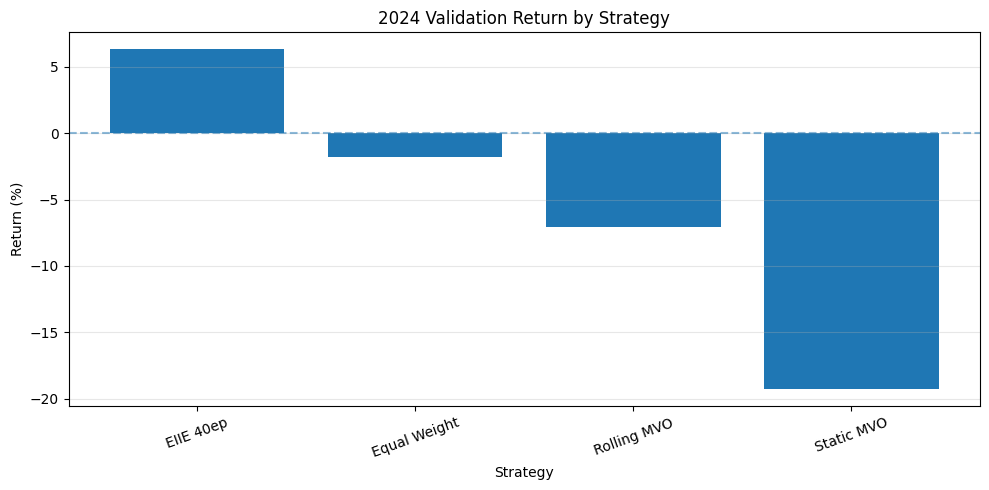

In [4]:
#2024 validation 전략 비교 그래프

validation_plot = (
    validation_summary
    .sort_values(
        "Return (%)",
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

plt.bar(
    validation_plot["Strategy"],
    validation_plot["Return (%)"]
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.title(
    "2024 Validation Return by Strategy"
)

plt.xlabel("Strategy")
plt.ylabel("Return (%)")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "comparison_2024_validation_return.png",
    dpi=200
)

plt.show()

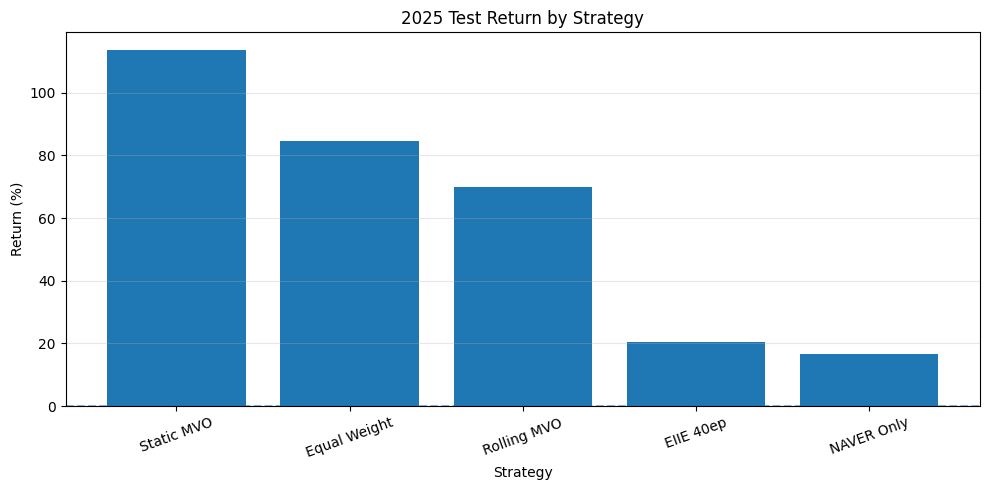

In [5]:
#2025 test 전략 비교

test_plot = (
    test_summary
    .sort_values(
        "Return (%)",
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

plt.bar(
    test_plot["Strategy"],
    test_plot["Return (%)"]
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.title(
    "2025 Test Return by Strategy"
)

plt.xlabel("Strategy")
plt.ylabel("Return (%)")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "comparison_2025_test_return.png",
    dpi=200
)

plt.show()

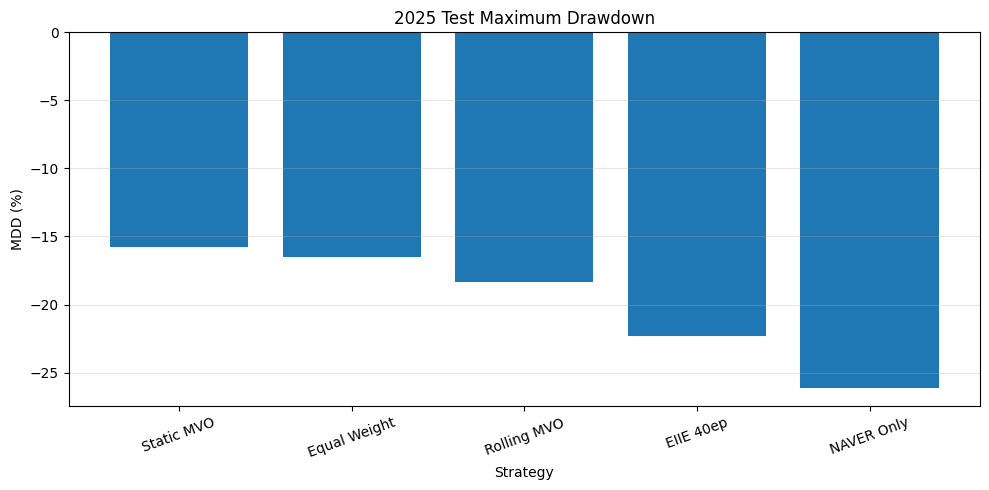

In [7]:
# 위험 비교
# mdd: maximum drawdown: 고점-저점 최대 낙폭

mdd_plot = (
    test_summary
    .sort_values(
        "MDD (%)",
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

plt.bar(
    mdd_plot["Strategy"],
    mdd_plot["MDD (%)"]
)

plt.title(
    "2025 Test Maximum Drawdown"
)

plt.xlabel("Strategy")
plt.ylabel("MDD (%)")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "comparison_2025_mdd.png",
    dpi=200
)

plt.show()

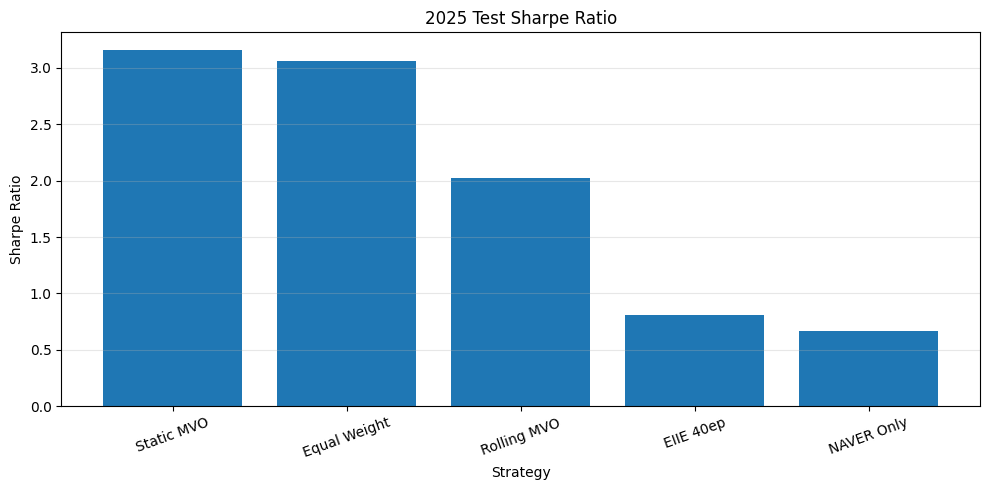

In [8]:
# sharpe

sharpe_plot = (
    test_summary
    .sort_values(
        "Sharpe",
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

plt.bar(
    sharpe_plot["Strategy"],
    sharpe_plot["Sharpe"]
)

plt.title(
    "2025 Test Sharpe Ratio"
)

plt.xlabel("Strategy")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "comparison_2025_sharpe.png",
    dpi=200
)

plt.show()

In [9]:
# 2025 자산곡선
# mvo

mvo_curves = pd.read_csv(
    RESULTS_DIR / "test_2025_mvo_curves.csv",
    index_col=0,
    parse_dates=True
)

mvo_curves.head()

,Static MVO,Rolling MVO,Equal Weight
2025-03-19,100000000.0,100000000.0,100000000.0
2025-03-20,102190800.0,101230896.0,101143032.0
2025-03-21,104539160.0,101589656.0,102323632.0
2025-03-24,103540736.0,101032784.0,102223168.0
2025-03-25,103031000.0,100687344.0,102389728.0


In [10]:
#eiie

eiie_curves = pd.read_csv(
    RESULTS_DIR / "test_2025_portfolio_value.csv",
    index_col=0,
    parse_dates=True
)

eiie_curves.head()

,EIIE 40ep,Dynamic Cash + NAVER,NAVER Only
2025-03-19,100000000.0,100000000.0,100000000.0
2025-03-20,100325304.0,100000000.0,100000000.0
2025-03-21,101164296.0,100677872.0,100721160.0
2025-03-24,99996896.0,99548416.0,99519232.0
2025-03-25,100119072.0,99774336.0,99759616.0


In [11]:
# 컬럼 확인

print(
    "MVO columns:",
    mvo_curves.columns.tolist()
)

print(
    "EIIE columns:",
    eiie_curves.columns.tolist()
)

MVO columns: ['Static MVO', 'Rolling MVO', 'Equal Weight']
EIIE columns: ['EIIE 40ep', 'Dynamic Cash + NAVER', 'NAVER Only']


In [12]:
# 합침

comparison_curves = pd.concat(
    [
        mvo_curves[
            [
                "Static MVO",
                "Rolling MVO",
                "Equal Weight"
            ]
        ],
        eiie_curves[
            [
                "EIIE 40ep",
                "NAVER Only"
            ]
        ]
    ],
    axis=1
)

comparison_curves.head()

,Static MVO,Rolling MVO,Equal Weight,EIIE 40ep,NAVER Only
2025-03-19,100000000.0,100000000.0,100000000.0,100000000.0,100000000.0
2025-03-20,102190800.0,101230896.0,101143032.0,100325304.0,100000000.0
2025-03-21,104539160.0,101589656.0,102323632.0,101164296.0,100721160.0
2025-03-24,103540736.0,101032784.0,102223168.0,99996896.0,99519232.0
2025-03-25,103031000.0,100687344.0,102389728.0,100119072.0,99759616.0


In [14]:
# 시작점 100으로 
# 100 = 시작 시점, 120 = +20%, 200 = +100%

normalized_curves = (
    comparison_curves
    / comparison_curves.iloc[0]
    * 100
)

normalized_curves.head()

,Static MVO,Rolling MVO,Equal Weight,EIIE 40ep,NAVER Only
2025-03-19,100.000000,100.000000,100.000000,100.000000,100.000000
2025-03-20,102.190800,101.230896,101.143032,100.325304,100.000000
2025-03-21,104.539160,101.589656,102.323632,101.164296,100.721160
2025-03-24,103.540736,101.032784,102.223168,99.996896,99.519232
2025-03-25,103.031000,100.687344,102.389728,100.119072,99.759616


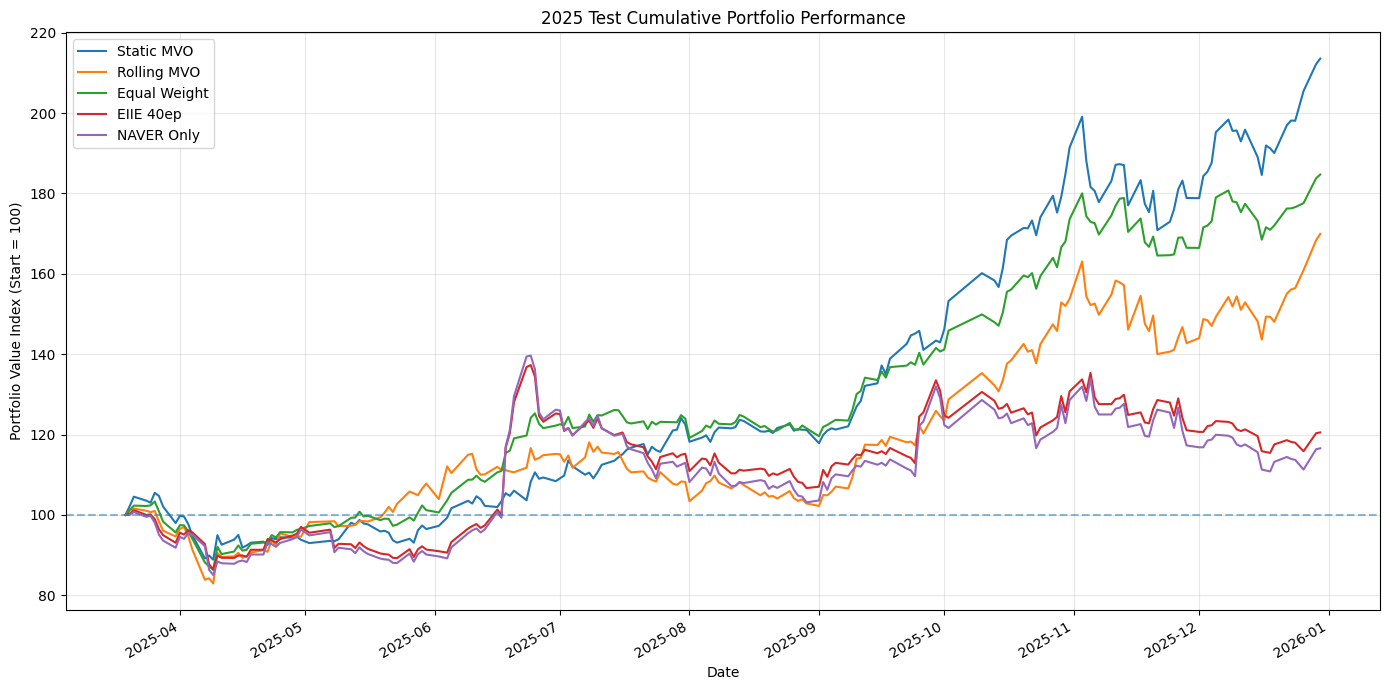

In [15]:
# 그래프

normalized_curves.plot(
    figsize=(14, 7)
)

plt.axhline(
    100,
    linestyle="--",
    alpha=0.5
)

plt.title(
    "2025 Test Cumulative Portfolio Performance"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value Index (Start = 100)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "comparison_2025_equity_curve.png",
    dpi=200
)

plt.show()

In [ ]:
#주안점
#언제 Static MVO가 급격히 상승했는지
#언제 EIIE가 상대적으로 부진했는지
#Rolling MVO는 언제 따라잡았는지
#Drawdown 구간이 어디였는지 

In [16]:
# EIIE 비중 그래프

eiie_weights = pd.read_csv(
    RESULTS_DIR
    / "test_2025_eiie_weights.csv",
    index_col=0,
    parse_dates=True
)

eiie_weights.head()

,Cash,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
2025-03-19,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2025-03-20,0.075167,0.000018,0.009318,0.114277,0.801208,0.000011
2025-03-21,0.060022,0.000015,0.007500,0.094297,0.838157,0.000009
2025-03-24,0.060082,0.000015,0.007625,0.092645,0.839623,0.000009
2025-03-25,0.060418,0.000015,0.007779,0.091657,0.840121,0.000010


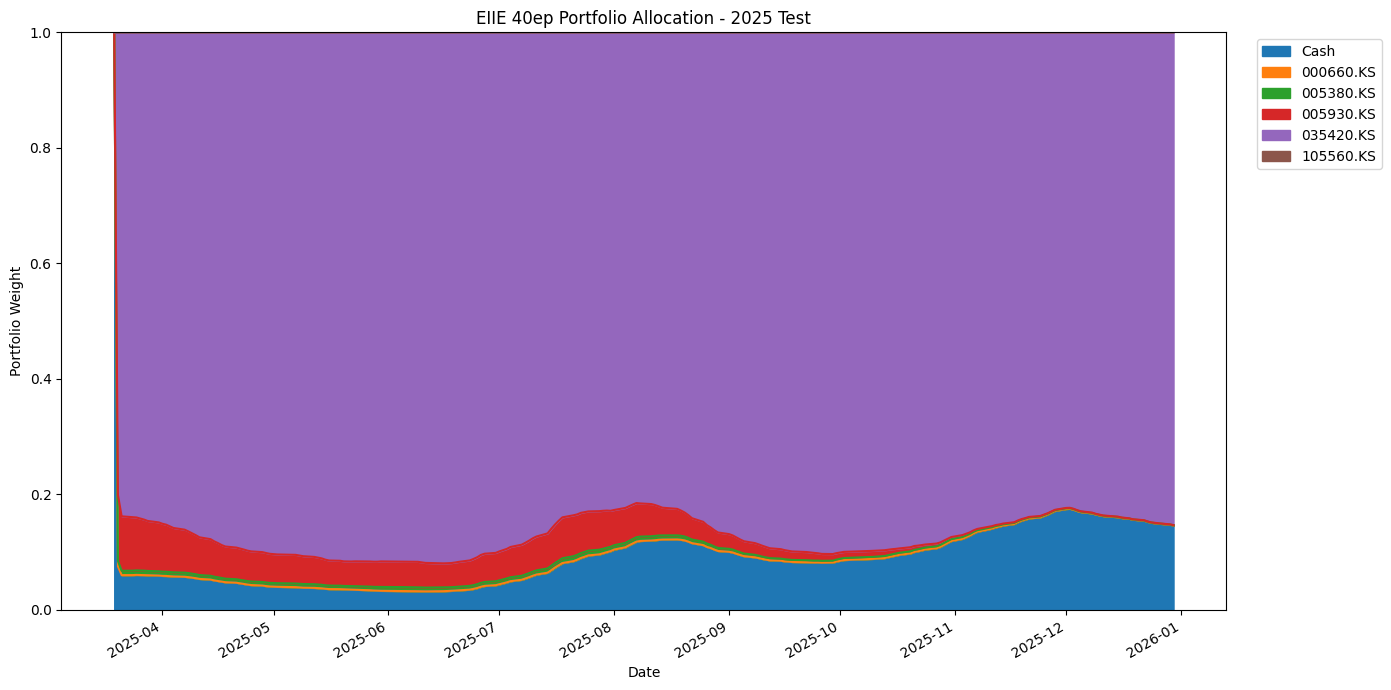

In [17]:
# stacked area chart

eiie_weights.plot.area(
    figsize=(14, 7)
)

plt.title(
    "EIIE 40ep Portfolio Allocation - 2025 Test"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Weight")

plt.ylim(0, 1)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "comparison_2025_eiie_allocation.png",
    dpi=200
)

plt.show()

In [19]:
#일간 수익률

strategy_daily_returns = (
    comparison_curves
    .pct_change()
    .dropna()
)

strategy_daily_returns.head()

,Static MVO,Rolling MVO,Equal Weight,EIIE 40ep,NAVER Only
2025-03-20,0.021908,0.012309,0.011430,0.003253,0.000000
2025-03-21,0.022980,0.003544,0.011673,0.008363,0.007212
2025-03-24,-0.009551,-0.005482,-0.000982,-0.011540,-0.011933
2025-03-25,-0.004923,-0.003419,0.001629,0.001222,0.002415
2025-03-26,0.024081,0.002994,0.009289,-0.011728,-0.016867


In [20]:
#EIIE와 NAVER 얼마나 비슷하게 움직였는지

strategy_corr = (
    strategy_daily_returns
    .corr()
)

strategy_corr

,Static MVO,Rolling MVO,Equal Weight,EIIE 40ep,NAVER Only
Static MVO,1.000000,0.692561,0.855293,0.287535,0.267723
Rolling MVO,0.692561,1.000000,0.837347,0.406099,0.404504
Equal Weight,0.855293,0.837347,1.000000,0.579791,0.568360
EIIE 40ep,0.287535,0.406099,0.579791,1.000000,0.998752
NAVER Only,0.267723,0.404504,0.568360,0.998752,1.000000


In [22]:
#1에 가까움→ 거의 같이 움직임, 0 근처→ 별 관계 없음, 1에 가까움→ 반대로 움직임

print(
    "EIIE vs NAVER correlation:",
    strategy_corr.loc[
        "EIIE 40ep",
        "NAVER Only"
    ]
)

print(
    "EIIE vs Static MVO correlation:",
    strategy_corr.loc[
        "EIIE 40ep",
        "Static MVO"
    ]
)

print(
    "EIIE vs Equal Weight correlation:",
    strategy_corr.loc[
        "EIIE 40ep",
        "Equal Weight"
    ]
)

EIIE vs NAVER correlation: 0.9987524461277332
EIIE vs Static MVO correlation: 0.28753463638050386
EIIE vs Equal Weight correlation: 0.5797909058394973


In [23]:
#전략별 월간 수익률

monthly_strategy_returns = (
    comparison_curves
    .resample("ME")
    .last()
    .pct_change()
    * 100
)

monthly_strategy_returns

,Static MVO,Rolling MVO,Equal Weight,EIIE 40ep,NAVER Only
2025-03-31,NaN,NaN,NaN,NaN,NaN
2025-04-30,-4.255535,-0.022066,0.925554,4.250478,4.973826
2025-05-31,2.852853,13.954122,4.838804,-5.824894,-6.483807
2025-06-30,12.350584,6.847919,20.800284,37.054724,39.999989
2025-07-31,12.978674,-6.063922,1.399298,-7.996439,-10.476197
2025-08-31,-1.066469,-4.945377,-1.912635,-7.417444,-8.723370
2025-09-30,17.973397,21.121668,15.707883,22.679824,25.174811
2025-10-31,33.939450,23.440032,23.405333,-0.099516,-0.372445
2025-11-30,-6.574137,-7.175859,-4.092022,-7.395266,-8.785043
2025-12-31,19.399951,19.059271,10.946745,-0.440232,-0.614773


In [24]:
#날짜 월 단위로

monthly_strategy_returns.index = (
    monthly_strategy_returns
    .index
    .strftime("%Y-%m")
)

monthly_strategy_returns.round(2)

,Static MVO,Rolling MVO,Equal Weight,EIIE 40ep,NAVER Only
2025-03,NaN,NaN,NaN,NaN,NaN
2025-04,-4.26,-0.02,0.93,4.25,4.97
2025-05,2.85,13.95,4.84,-5.82,-6.48
2025-06,12.35,6.85,20.80,37.05,40.00
2025-07,12.98,-6.06,1.40,-8.00,-10.48
2025-08,-1.07,-4.95,-1.91,-7.42,-8.72
2025-09,17.97,21.12,15.71,22.68,25.17
2025-10,33.94,23.44,23.41,-0.10,-0.37
2025-11,-6.57,-7.18,-4.09,-7.40,-8.79
2025-12,19.40,19.06,10.95,-0.44,-0.61


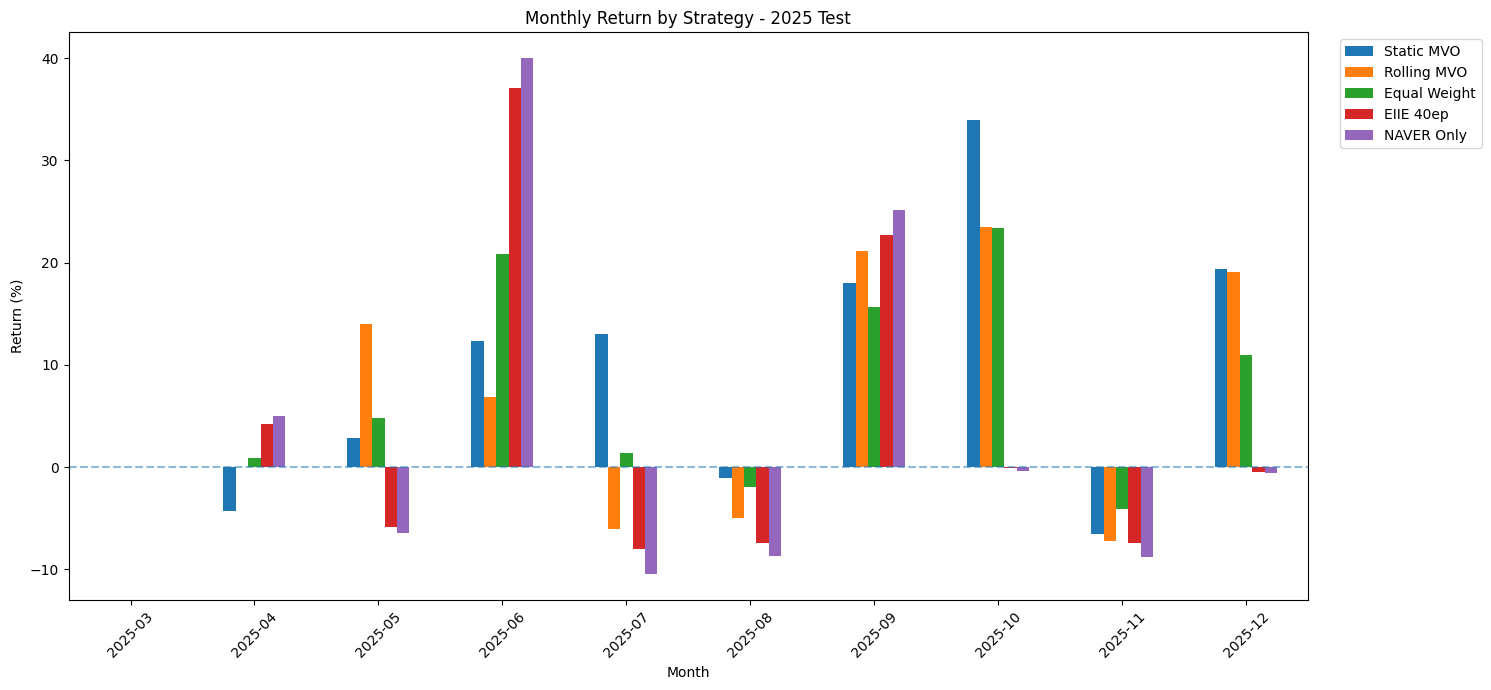

In [25]:
#월별 수익률 그래프

monthly_strategy_returns.plot(
    kind="bar",
    figsize=(15, 7)
)

plt.axhline(
    0,
    linestyle="--",
    alpha=0.5
)

plt.title(
    "Monthly Return by Strategy - 2025 Test"
)

plt.xlabel("Month")
plt.ylabel("Return (%)")

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR
    / "comparison_2025_monthly_returns.png",
    dpi=200
)

plt.show()

In [29]:
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader

KOREA_STOCKS = [
    "005930.KS",
    "000660.KS",
    "005380.KS",
    "035420.KS",
    "105560.KS"
]

START_DATE = "2018-01-01"
END_DATE = "2026-01-01"

portfolio_raw_df = YahooDownloader(
    start_date=START_DATE,
    end_date=END_DATE,
    ticker_list=KOREA_STOCKS
).fetch_data()

portfolio_raw_df["date"] = pd.to_datetime(
    portfolio_raw_df["date"]
)

#5종목 공통 거래일

date_counts = (
    portfolio_raw_df
    .groupby("date")["tic"]
    .nunique()
)

common_dates = date_counts[
    date_counts == len(KOREA_STOCKS)
].index

portfolio_raw_df = (
    portfolio_raw_df[
        portfolio_raw_df["date"].isin(common_dates)
    ]
    .sort_values(["date", "tic"])
    .reset_index(drop=True)
)

#prices 생성
prices = (
    portfolio_raw_df
    .pivot(
        index="date",
        columns="tic",
        values="close"
    )
    .sort_index()
)

prices.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (9800, 8)


tic,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
date,,,,,
2018-01-02,69346.695312,110675.718750,41160.601562,171199.265625,43072.519531
2018-01-03,70342.539062,111416.015625,41644.664062,168491.031250,43072.519531
2018-01-04,69799.343750,108454.789062,41209.015625,172746.828125,43004.269531
2018-01-05,71791.031250,110305.570312,42048.042969,175648.500000,43755.136719
2018-01-08,70795.203125,111786.179688,41967.367188,183773.234375,45461.652344


In [30]:
#종목별 월간 수익률

stock_test_prices = prices.loc[
    (prices.index >= comparison_curves.index.min())
    & (prices.index <= comparison_curves.index.max())
]

monthly_stock_returns = (
    stock_test_prices
    .resample("ME")
    .last()
    .pct_change()
    * 100
)

monthly_stock_returns.index = (
    monthly_stock_returns
    .index
    .strftime("%Y-%m")
)

monthly_stock_returns.round(2)

tic,000660.KS,005380.KS,005930.KS,035420.KS,105560.KS
date,,,,,
2025-03,NaN,NaN,NaN,NaN,NaN
2025-04,-6.92,-3.35,-3.98,4.97,14.18
2025-05,15.42,-1.46,1.26,-6.48,16.76
2025-06,42.79,9.82,7.06,40.00,6.33
2025-07,-6.34,4.67,19.40,-10.48,0.00
2025-08,-1.50,4.47,-2.38,-8.72,-1.65
2025-09,29.18,-2.27,20.91,25.17,6.75
2025-10,60.86,34.88,28.13,-0.37,0.95
2025-11,-5.12,-8.96,-6.51,-8.79,7.78


In [31]:
#market breadth: 얼마나 많은 종목이 같이 상승하고 있느냐

stock_daily_returns = (
    stock_test_prices
    .pct_change()
)

market_breadth = (
    (stock_daily_returns > 0)
    .sum(axis=1)
    / len(KOREA_STOCKS)
)

market_breadth.head()

date
2025-03-19    0.0
2025-03-20    0.6
2025-03-21    0.8
2025-03-24    0.4
2025-03-25    0.6
dtype: float64

In [32]:
#20일 이동평균

breadth_20d = (
    market_breadth
    .rolling(20)
    .mean()
)

In [34]:
%matplotlib inline

import matplotlib.pyplot as plt

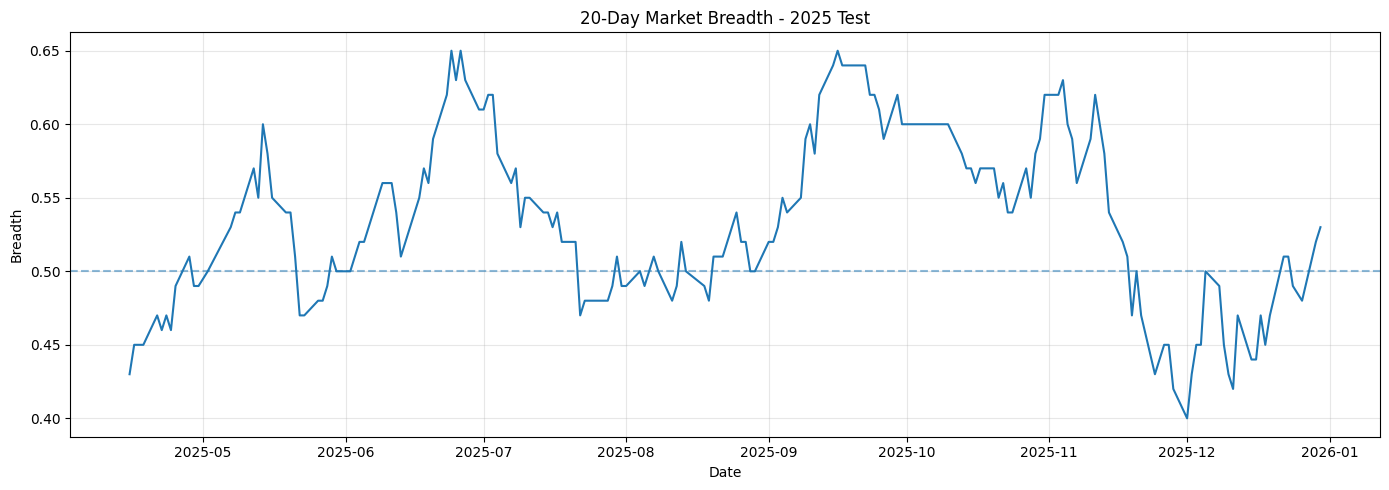

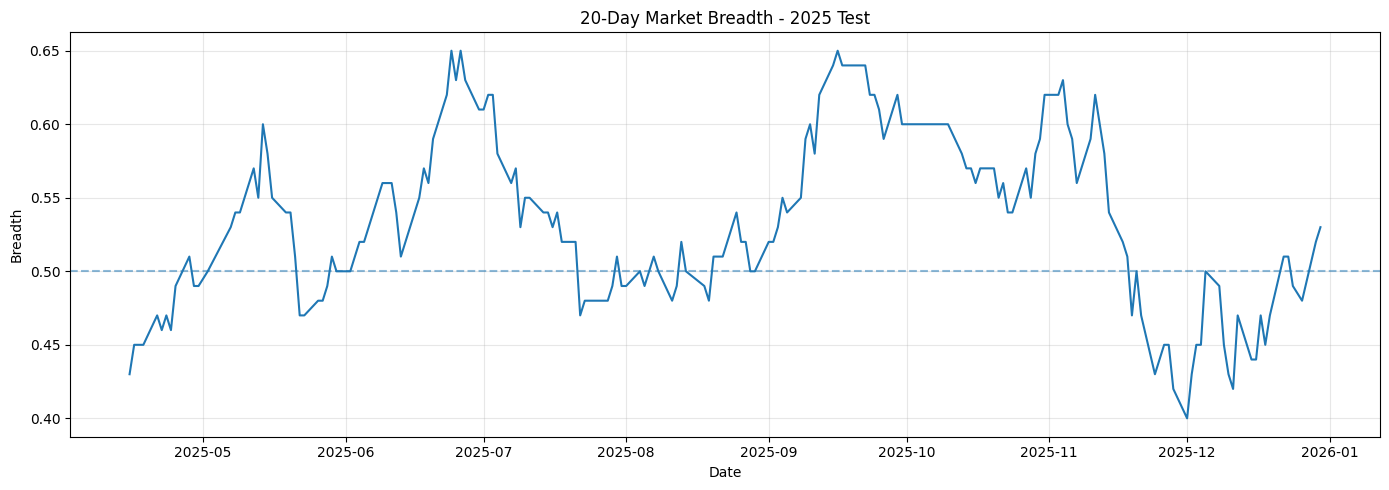

In [35]:
#그래프

plt.figure(figsize=(14, 5))

plt.plot(
    breadth_20d.index,
    breadth_20d
)

plt.axhline(
    0.5,
    linestyle="--",
    alpha=0.5
)

plt.title(
    "20-Day Market Breadth - 2025 Test"
)

plt.xlabel("Date")
plt.ylabel("Breadth")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [38]:
stock_daily_returns = (
    stock_test_prices
    .pct_change()
)

market_breadth = (
    (stock_daily_returns > 0)
    .sum(axis=1)
    / len(KOREA_STOCKS)
)

# 수익률을 계산할 수 없는 첫 날짜는 NaN 처리
market_breadth.loc[
    stock_daily_returns.isna().all(axis=1)
] = np.nan

market_breadth.head()

date
2025-03-19    NaN
2025-03-20    0.6
2025-03-21    0.8
2025-03-24    0.4
2025-03-25    0.6
dtype: float64

In [44]:
#같은 날 5종목의 수익률 차이가 얼마나 큰가?

breadth_20d = (
    market_breadth
    .rolling(20)
    .mean()
)

dispersion_20d.head(30)

date
2025-03-19         NaN
2025-03-20         NaN
2025-03-21         NaN
2025-03-24         NaN
2025-03-25         NaN
2025-03-26         NaN
2025-03-27         NaN
2025-03-28         NaN
2025-03-31         NaN
2025-04-01         NaN
2025-04-02         NaN
2025-04-03         NaN
2025-04-04         NaN
2025-04-07         NaN
2025-04-08         NaN
2025-04-09         NaN
2025-04-10         NaN
2025-04-11         NaN
2025-04-14         NaN
2025-04-15         NaN
2025-04-16    0.019067
2025-04-17    0.018548
2025-04-18    0.018449
2025-04-21    0.017408
2025-04-22    0.017421
2025-04-23    0.017287
2025-04-24    0.016615
2025-04-25    0.016904
2025-04-28    0.016342
2025-04-29    0.016268
dtype: float64

In [45]:
print(
    "Breadth 첫 유효 날짜:",
    breadth_20d.first_valid_index()
)

breadth_20d.dropna().head()

Breadth 첫 유효 날짜: 2025-04-16 00:00:00


date
2025-04-16    0.45
2025-04-17    0.45
2025-04-18    0.45
2025-04-21    0.47
2025-04-22    0.46
dtype: float64

In [46]:
print(
    "Breadth 첫 유효 날짜:",
    breadth_20d.first_valid_index()
)

print(
    "Momentum 첫 유효 날짜:",
    momentum_20d.first_valid_index()
)

print(
    "Dispersion 첫 유효 날짜:",
    dispersion_20d.first_valid_index()
)

Breadth 첫 유효 날짜: 2025-04-16 00:00:00
Momentum 첫 유효 날짜: 2025-04-16 00:00:00
Dispersion 첫 유효 날짜: 2025-04-16 00:00:00


In [47]:
#하나로 묶음

regime_features = pd.DataFrame({
    "Breadth_20D": breadth_20d,
    "Momentum_20D": momentum_20d,
    "Dispersion_20D": dispersion_20d
})

regime_features = (
    regime_features
    .dropna()
)

print(
    "Regime feature start:",
    regime_features.index.min()
)

print(
    "Regime feature end:",
    regime_features.index.max()
)

print(
    "Shape:",
    regime_features.shape
)

regime_features.head()

Regime feature start: 2025-04-16 00:00:00
Regime feature end: 2025-12-30 00:00:00
Shape: (172, 3)


,Breadth_20D,Momentum_20D,Dispersion_20D
date,,,
2025-04-16,0.45,-0.088275,0.019067
2025-04-17,0.45,-0.096330,0.018548
2025-04-18,0.45,-0.092261,0.018449
2025-04-21,0.47,-0.088425,0.017408
2025-04-22,0.46,-0.088465,0.017421


In [48]:
#통계

regime_features.describe()

#Breadth_20D → 최근 20일 동안 5종목 중 얼마나 많은 종목이 함께 상승했는가

#Momentum_20D → 5종목 전체가 최근 20일 동안 상승 추세였는가 / 하락 추세였는가

#Dispersion_20D → 최근 20일 동안 종목별 수익률 차이가 얼마나 컸는가

,Breadth_20D,Momentum_20D,Dispersion_20D
count,172.000000,172.000000,172.000000
mean,0.532035,0.077552,0.020085
std,0.058148,0.088449,0.003927
min,0.400000,-0.096330,0.013973
25%,0.490000,0.003486,0.016422
50%,0.530000,0.066845,0.020137
75%,0.572500,0.150977,0.023919
max,0.650000,0.273365,0.027004


In [49]:
#월 단위 요약

monthly_regime = (
    regime_features
    .resample("ME")
    .mean()
)

monthly_regime.index = (
    monthly_regime
    .index
    .strftime("%Y-%m")
)

monthly_regime.round(4)

,Breadth_20D,Momentum_20D,Dispersion_20D
date,,,
2025-04,0.4718,-0.0584,0.0174
2025-05,0.5237,0.0732,0.0152
2025-06,0.5721,0.1522,0.0189
2025-07,0.5330,0.0858,0.0242
2025-08,0.5030,-0.0117,0.0184
2025-09,0.5938,0.0816,0.0166
2025-10,0.5733,0.1938,0.0243
2025-11,0.5295,0.1094,0.0242
2025-12,0.4667,0.0271,0.0201


In [50]:
#monthly_strategy_returns와 합침

monthly_analysis = pd.concat(
    [
        monthly_regime,
        monthly_strategy_returns
    ],
    axis=1
)

monthly_analysis.round(2)

,Breadth_20D,Momentum_20D,Dispersion_20D,Static MVO,Rolling MVO,Equal Weight,EIIE 40ep,NAVER Only
2025-04,0.47,-0.06,0.02,-4.26,-0.02,0.93,4.25,4.97
2025-05,0.52,0.07,0.02,2.85,13.95,4.84,-5.82,-6.48
2025-06,0.57,0.15,0.02,12.35,6.85,20.80,37.05,40.00
2025-07,0.53,0.09,0.02,12.98,-6.06,1.40,-8.00,-10.48
2025-08,0.50,-0.01,0.02,-1.07,-4.95,-1.91,-7.42,-8.72
2025-09,0.59,0.08,0.02,17.97,21.12,15.71,22.68,25.17
2025-10,0.57,0.19,0.02,33.94,23.44,23.41,-0.10,-0.37
2025-11,0.53,0.11,0.02,-6.57,-7.18,-4.09,-7.40,-8.79
2025-12,0.47,0.03,0.02,19.40,19.06,10.95,-0.44,-0.61
2025-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
#EIIE와 NAVER가 정말 거의 같은 전략인지 수치로 확인

strategy_daily_returns = (
    comparison_curves
    .pct_change()
    .dropna()
)

strategy_corr = (
    strategy_daily_returns
    .corr()
)

print(
    "EIIE vs NAVER:",
    strategy_corr.loc[
        "EIIE 40ep",
        "NAVER Only"
    ]
)

print(
    "EIIE vs Static MVO:",
    strategy_corr.loc[
        "EIIE 40ep",
        "Static MVO"
    ]
)

print(
    "EIIE vs Equal Weight:",
    strategy_corr.loc[
        "EIIE 40ep",
        "Equal Weight"
    ]
)

EIIE vs NAVER: 0.9987524461277332
EIIE vs Static MVO: 0.28753463638050386
EIIE vs Equal Weight: 0.5797909058394973


In [52]:
#EIIE 집중도
#HHI: herfindahl-hirschman index: 시장 집중도 측정

weights_for_concentration = (
    eiie_weights
    .iloc[1:]
    .copy()
)

eiie_hhi = (
    weights_for_concentration
    .pow(2)
    .sum(axis=1)
)

effective_assets = (
    1 / eiie_hhi
)

print(
    "Average HHI:",
    eiie_hhi.mean()
)

print(
    "Average Effective Number of Assets:",
    effective_assets.mean()
)

print(
    "Average Max Weight:",
    weights_for_concentration
    .max(axis=1)
    .mean()
)

Average HHI: 0.7724539705041646
Average Effective Number of Assets: 1.3000792892723008
Average Max Weight: 0.8716037859162304


In [53]:
#매월 어떤 전략이 이겼는가

strategy_columns = [
    "Static MVO",
    "Rolling MVO",
    "Equal Weight",
    "EIIE 40ep",
    "NAVER Only"
]

monthly_analysis_clean = (
    monthly_analysis
    .dropna()
    .copy()
)

monthly_analysis_clean["Winner"] = (
    monthly_analysis_clean[
        strategy_columns
    ]
    .idxmax(axis=1)
)

monthly_analysis_clean[
    "Winner Return (%)"
] = (
    monthly_analysis_clean[
        strategy_columns
    ]
    .max(axis=1)
)

monthly_analysis_clean.round(2)

,Breadth_20D,Momentum_20D,Dispersion_20D,Static MVO,Rolling MVO,Equal Weight,EIIE 40ep,NAVER Only,Winner,Winner Return (%)
2025-04,0.47,-0.06,0.02,-4.26,-0.02,0.93,4.25,4.97,NAVER Only,4.97
2025-05,0.52,0.07,0.02,2.85,13.95,4.84,-5.82,-6.48,Rolling MVO,13.95
2025-06,0.57,0.15,0.02,12.35,6.85,20.80,37.05,40.00,NAVER Only,40.00
2025-07,0.53,0.09,0.02,12.98,-6.06,1.40,-8.00,-10.48,Static MVO,12.98
2025-08,0.50,-0.01,0.02,-1.07,-4.95,-1.91,-7.42,-8.72,Static MVO,-1.07
2025-09,0.59,0.08,0.02,17.97,21.12,15.71,22.68,25.17,NAVER Only,25.17
2025-10,0.57,0.19,0.02,33.94,23.44,23.41,-0.10,-0.37,Static MVO,33.94
2025-11,0.53,0.11,0.02,-6.57,-7.18,-4.09,-7.40,-8.79,Equal Weight,-4.09
2025-12,0.47,0.03,0.02,19.40,19.06,10.95,-0.44,-0.61,Static MVO,19.40


In [ ]:
#결론
#EIIE는 2024 Validation에서 우수한 성과를 보였지만 2025에는 NAVER에 약 87%를 집중하는 정책으로 수렴했고,
#일간 수익률 또한 NAVER Only와 0.999에 가까운 상관관계를 보였다.
#반면 MVO와 Equal Weight 전략은 2025 후반 반도체·자동차 중심의 상승 국면에서 높은 성과를 기록했다.
#따라서 단일 전략의 우월성보다는 시장 상태 및 주도 종목 변화에 따라 전략의 상대 성과가
#달라지는 현상이 관찰되었다.

In [54]:
regime_features.to_csv(
    RESULTS_DIR / "regime_features_2025.csv",
    encoding="utf-8-sig"
)

monthly_analysis_clean.to_csv(
    RESULTS_DIR / "monthly_regime_strategy_analysis_2025.csv",
    encoding="utf-8-sig"
)

print("저장 완료")

저장 완료


In [55]:
eiie_concentration_summary = pd.DataFrame({
    "Metric": [
        "EIIE_NAVER_Correlation",
        "Average_HHI",
        "Effective_Number_of_Assets",
        "Average_Max_Weight"
    ],
    "Value": [
        0.9987524461,
        eiie_hhi.mean(),
        effective_assets.mean(),
        weights_for_concentration.max(axis=1).mean()
    ]
})

eiie_concentration_summary.to_csv(
    RESULTS_DIR / "eiie_concentration_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")

저장 완료


In [56]:
stock_test_prices.to_csv(
    RESULTS_DIR / "stock_prices_2025.csv",
    encoding="utf-8-sig"
)

print("2025 stock prices 저장 완료")

2025 stock prices 저장 완료
